In [1]:
import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import sys; sys.path.append('../')
import torch
from functools import singledispatch
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import normalize
from asterism.core.lda import GibbsLDA, GibbsSLDA, PyroLDA
from asterism.core.ncp import split, NCP
from asterism.core.ntm import ATLAS, NTM, RSB
from asterism.core.vae import VQAE
from asterism.utils.data import make_dataset
from asterism.utils.plots import show_comparison, show_dataset

/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
def remove_lonely(X, locs, y=None, k=12, cutoff=128.):
    adj = torch.cdist(locs, locs).sort(-1).values
    mask = adj[:, :k].mean(-1) < cutoff
    X, locs = X[mask], locs[mask]

    if y is not None:
        y = y[mask]

        return X, locs, y
    return X, locs

/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


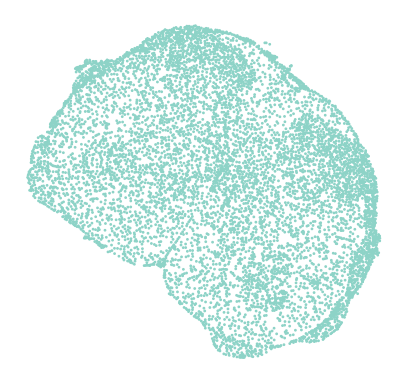

In [3]:
datasets = ['s13t02g93am06', 's13t12g93am06', 's13t06g93am04', 's13b02b6jlm06', 's13b12b6jlm06', 's13b06b6jlm04']
adata = mu.read(f'data/miil/{datasets[0]}.h5mu')
common_obs = adata['morphological'].obs_names.intersection(adata['protein'].obs_names).intersection(adata['imagenet'].obs_names)
morphological_data = adata['morphological'][common_obs]
img = torch.zeros((len(morphological_data), 1), dtype=torch.float32)
x, y = torch.tensor(morphological_data.obsm['spatial'].T, dtype=torch.float32)
protein_data = torch.tensor(adata['protein'][common_obs].X, dtype=torch.float32)
imagenet_data = torch.tensor(adata['imagenet'][common_obs].X, dtype=torch.float32)
data0 = torch.hstack([img, x[:, None], y[:, None], protein_data, imagenet_data])
data0, locs0 = remove_lonely(data0[:, 3:], data0[:, :3], k=12, cutoff=128.)
x_mask, y_mask = locs0[:, 1] < 7000, locs0[:, 2] < 6000
data0, locs0 = data0[x_mask*y_mask], locs0[x_mask*y_mask]
data0 = (data0 - data0.mean(0)[None])/data0.std(0)[None]
show_dataset(locs0, size=1)

/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


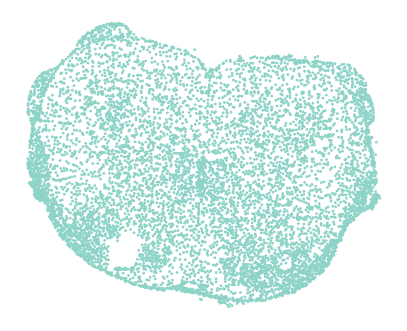

In [4]:
adata = mu.read(f'data/miil/{datasets[1]}.h5mu')
common_obs = adata['morphological'].obs_names.intersection(adata['protein'].obs_names).intersection(adata['imagenet'].obs_names)
morphological_data = adata['morphological'][common_obs]
img = torch.zeros((len(morphological_data), 1), dtype=torch.float32)
x, y = torch.tensor(morphological_data.obsm['spatial'].T, dtype=torch.float32)
protein_data = torch.tensor(adata['protein'][common_obs].X, dtype=torch.float32)
imagenet_data = torch.tensor(adata['imagenet'][common_obs].X, dtype=torch.float32)
data1 = torch.hstack([img, x[:, None], y[:, None], protein_data, imagenet_data])
data1, locs1 = remove_lonely(data1[:, 3:], data1[:, :3], k=12, cutoff=128.)
x_mask, y_mask = locs1[:, 1] < 7000, locs1[:, 2] < 6000
data1, locs1 = data1[x_mask*y_mask], locs1[x_mask*y_mask]
data1 = (data1 - data1.mean(0)[None])/data1.std(0)[None]
show_dataset(locs1, size=1)

/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


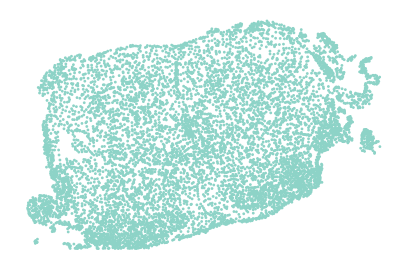

In [5]:
adata = mu.read(f'data/miil/{datasets[2]}.h5mu')
common_obs = adata['morphological'].obs_names.intersection(adata['protein'].obs_names).intersection(adata['imagenet'].obs_names)
morphological_data = adata['morphological'][common_obs]
img = torch.zeros((len(morphological_data), 1), dtype=torch.float32)
x, y = torch.tensor(morphological_data.obsm['spatial'].T, dtype=torch.float32)
protein_data = torch.tensor(adata['protein'][common_obs].X, dtype=torch.float32)
imagenet_data = torch.tensor(adata['imagenet'][common_obs].X, dtype=torch.float32)
data2 = torch.hstack([img, x[:, None], y[:, None], protein_data, imagenet_data])
data2, locs2 = remove_lonely(data2[:, 3:], data2[:, :3], k=12, cutoff=128.)
data2 = (data2 - data2.mean(0)[None])/data2.std(0)[None]
show_dataset(locs2, size=1)

/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


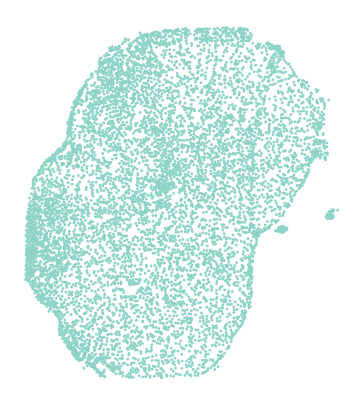

In [6]:
adata = mu.read(f'data/miil/{datasets[3]}.h5mu')
common_obs = adata['morphological'].obs_names.intersection(adata['protein'].obs_names).intersection(adata['imagenet'].obs_names)
morphological_data = adata['morphological'][common_obs]
img = torch.zeros((len(morphological_data), 1), dtype=torch.float32)
x, y = torch.tensor(morphological_data.obsm['spatial'].T, dtype=torch.float32)
protein_data = torch.tensor(adata['protein'][common_obs].X, dtype=torch.float32)
imagenet_data = torch.tensor(adata['imagenet'][common_obs].X, dtype=torch.float32)
data3 = torch.hstack([img, x[:, None], y[:, None], protein_data, imagenet_data])
data3, locs3 = remove_lonely(data3[:, 3:], data3[:, :3], k=12, cutoff=128.)
data3 = (data3 - data3.mean(0)[None])/data3.std(0)[None]
show_dataset(locs3, size=1)

/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


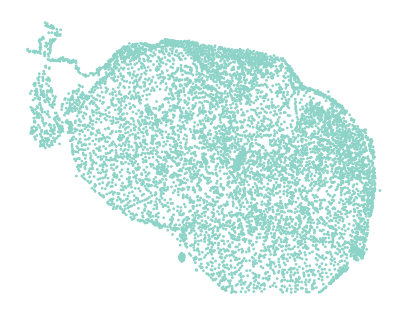

In [7]:
adata = mu.read(f'data/miil/{datasets[4]}.h5mu')
common_obs = adata['morphological'].obs_names.intersection(adata['protein'].obs_names).intersection(adata['imagenet'].obs_names)
morphological_data = adata['morphological'][common_obs]
img = torch.zeros((len(morphological_data), 1), dtype=torch.float32)
x, y = torch.tensor(morphological_data.obsm['spatial'].T, dtype=torch.float32)
protein_data = torch.tensor(adata['protein'][common_obs].X, dtype=torch.float32)
imagenet_data = torch.tensor(adata['imagenet'][common_obs].X, dtype=torch.float32)
data4 = torch.hstack([img, x[:, None], y[:, None], protein_data, imagenet_data])
data4, locs4 = remove_lonely(data4[:, 3:], data4[:, :3], k=12, cutoff=128.)
x_mask = 1000 < locs4[:, 1]
data4, locs4 = data4[x_mask], locs4[x_mask]
data4 = (data4 - data4.mean(0)[None])/data4.std(0)[None]
show_dataset(locs4, size=1)

/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


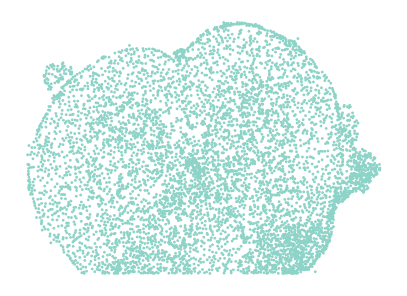

In [8]:
adata = mu.read(f'data/miil/{datasets[5]}.h5mu')
common_obs = adata['morphological'].obs_names.intersection(adata['protein'].obs_names).intersection(adata['imagenet'].obs_names)
morphological_data = adata['morphological'][common_obs]
img = torch.zeros((len(morphological_data), 1), dtype=torch.float32)
x, y = torch.tensor(morphological_data.obsm['spatial'].T, dtype=torch.float32)
protein_data = torch.tensor(adata['protein'][common_obs].X, dtype=torch.float32)
imagenet_data = torch.tensor(adata['imagenet'][common_obs].X, dtype=torch.float32)
data5 = torch.hstack([img, x[:, None], y[:, None], protein_data, imagenet_data])
data5, locs5 = remove_lonely(data5[:, 3:], data5[:, :3], k=12, cutoff=128.)
x_mask, y_mask = 1000 < locs5[:, 1], locs5[:, 2] < 7000
data5, locs5 = data5[x_mask*y_mask], locs5[x_mask*y_mask]
data5 = (data5 - data5.mean(0)[None])/data5.std(0)[None]
show_dataset(locs5, size=1)

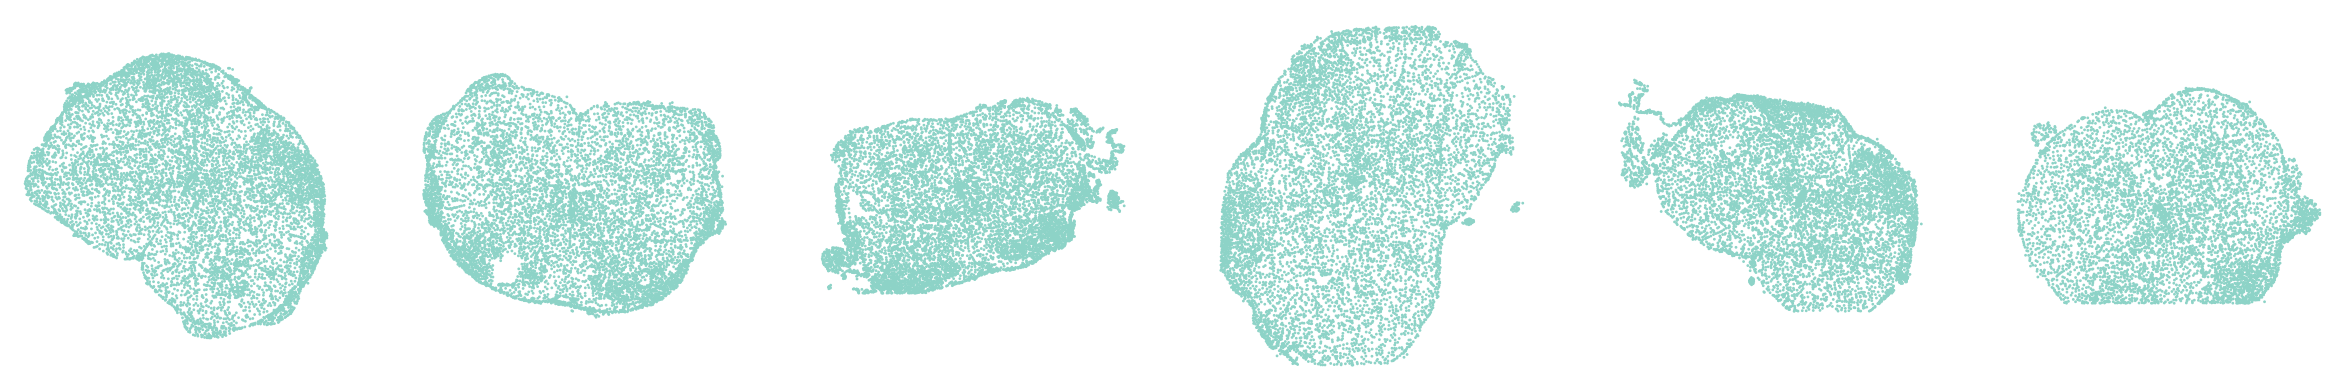

In [9]:
data = torch.cat([data0, data1, data2, data3, data4, data5])
locs1[:, 0] = 1
locs2[:, 0] = 2
locs3[:, 0] = 3
locs4[:, 0] = 4
locs5[:, 0] = 5
locs = torch.cat([locs0, locs1, locs2, locs3, locs4, locs5])
show_dataset(locs, size=1)

ATLAS: 100%|██████████| 200/200 [04:21<00:00,  1.31s/it]


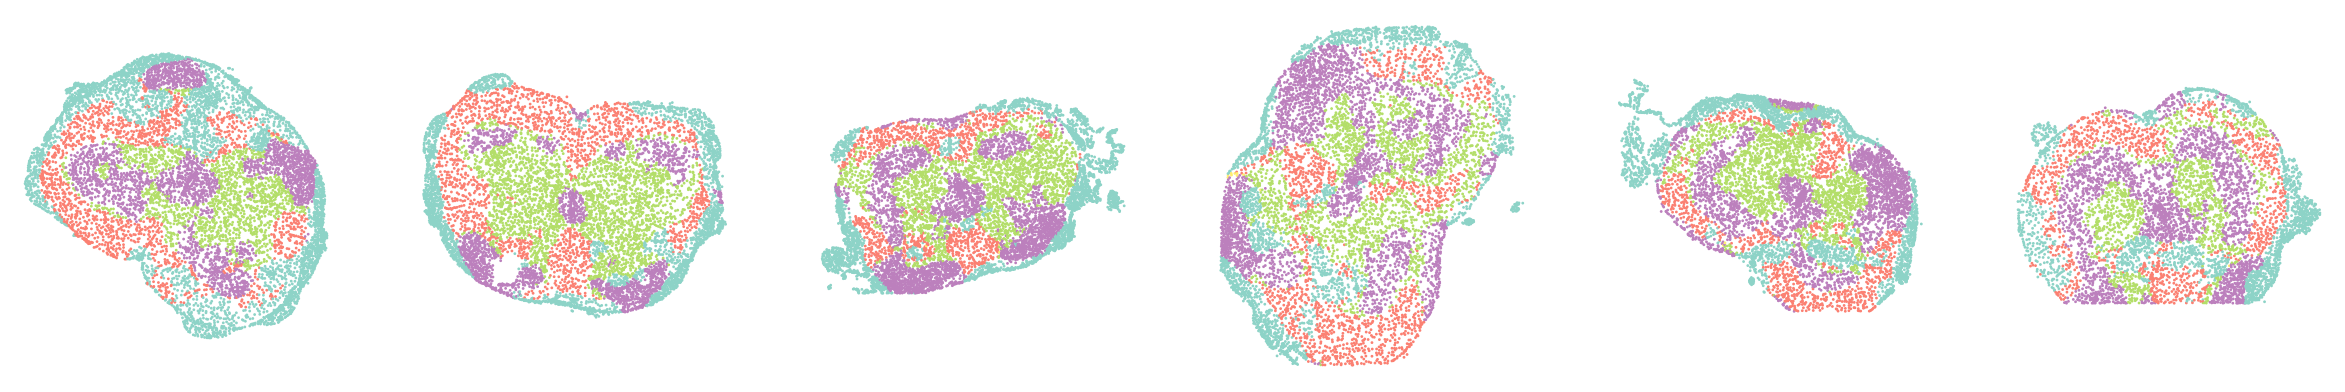

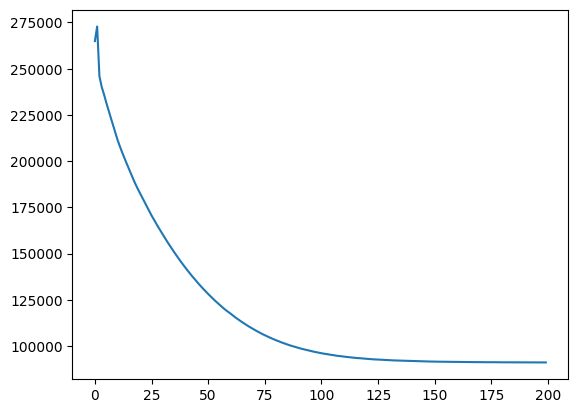

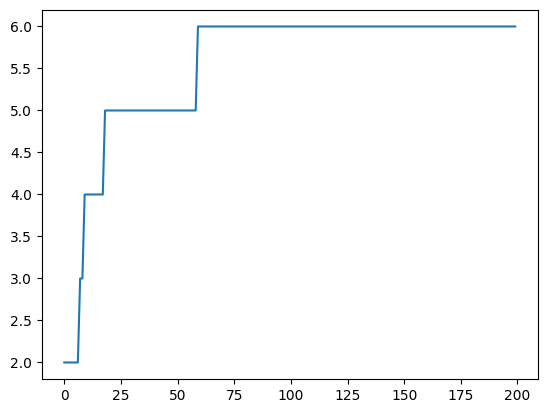

In [10]:
model = ATLAS(doc_size=64, topic_rate=.1)
topics = model.fit_predict(data, locs, n_steps=200)
show_dataset(locs, topics, size=1)
plt.plot(range(len(model.log_)), model.log_)
plt.show()
plt.plot(range(len(model.topic_log_)), model.topic_log_)
plt.show()

In [35]:
'''
Authors: Craig Fouts
Contact: c.fouts25@imperial.ac.uk
License: Apache 2.0 license
'''

from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torch_geometric.nn.conv import SimpleConv
from asterism.base import AsterismSpatial, Encoder, MLP, RNN
from asterism.utils import knn2D
from asterism.utils.nets import OPTIMS
from asterism.utils.sugar import attrmethod

from torch_geometric.nn import GCN

__all__ = [
    'ATLAS'
]

class ATLAS(AsterismSpatial, nn.Module):
    @attrmethod
    def __init__(self, min_topics=1, *, channels=(128, 32), doc_size=8, topic_rate=.1, kld_scale=.1, optim='adam', desc='ATLAS', seed=None):
        super().__init__(desc, seed, torch_state=True)

        self._channels = (channels,) if isinstance(channels, int) else channels
        self._n_steps = 1000
        self.n_topics_ = min_topics
        self.topic_log_ = []

    def _build(self, X, locs, learning_rate=1e-2, batch_size=32, shuffle=True):
        if batch_size == -1:
            batch_size = len(X)

        # self._X = SimpleConv(aggr='mean')(X, knn2D(locs, self.doc_size))
        self._X = X
        self._E = knn2D(locs, self.doc_size)
        self._loader = DataLoader(self._X, len(X), shuffle=False)

        # self._encoder = Encoder(in_channels := X.shape[1], *self._channels, act_layer='prelu', seed=self._state)
        self._encoder = GCN(in_channels := X.shape[1], 128, 1, self._channels[-1], dropout=.5, norm='batch')

        self._dt_rnn = RNN(out_channels := self._channels[-1], bias=False, act_layer='prelu', seed=self._state)
        self._tw_rnn = RNN(out_channels, bias=False, act_layer='prelu', seed=self._state)
        self._decoder = MLP(out_channels, in_channels, final_bias=False)
        self._optim = OPTIMS[self.optim](self.parameters(), lr=learning_rate)
        self.train()

        return self
    
    def _generate(self, Z=None, n_topics=-1):
        if n_topics == -1:
            n_topics = self.n_topics_

        weights = self._decoder(self._tw_rnn(n_layers=n_topics + 1))

        if Z is not None:
            X = F.softmax(Z@self._dt_rnn(n_layers=n_topics + 1).T, -1)@weights

            return X, weights
        return weights
    
    def _evaluate(self, X):
        # Z, kld = self._encoder(X, return_kld=True)
        Z = self._encoder(X, self._E)

        X_k, _ = self._generate(Z, self.n_topics_ - 1)
        X_K, weights = self._generate(Z)
        loss_k = (X_k - X).square().sum(1)/(n := len(X))
        loss_K = (X_K - X).square().sum(-1)/n
        loss = loss_K.sum().sqrt()  # + self.kld_scale*kld
        n_used = len((X@weights.T).argmax(-1).unique())
        increase = (loss_k - loss_K).sum()/loss_K.sum()

        if (self.n_topics_ <= n_used) and (self.topic_rate < increase):
            self.n_topics_ += 1

        return loss
    
    def _step(self):
        loss = 0.

        for X in self._loader:
            X_loss = self._evaluate(X)
            X_loss.backward()
            loss += X_loss.item()

        self._optim.step()
        self._optim.zero_grad()
        self.topic_log_.append(self.n_topics_)

        return loss
    
    def _predict(self, X, locs, train=False):
        if not train:
            self.eval()

        weights = self._X@self._generate().T
        topics = weights.argmax(-1).detach()

        return topics

ATLAS: 100%|██████████| 800/800 [05:49<00:00,  2.29it/s]


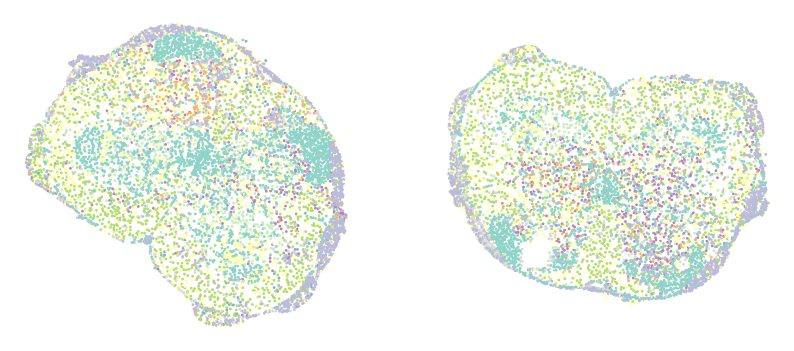

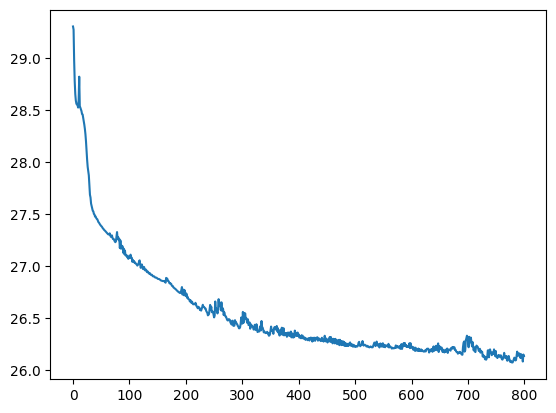

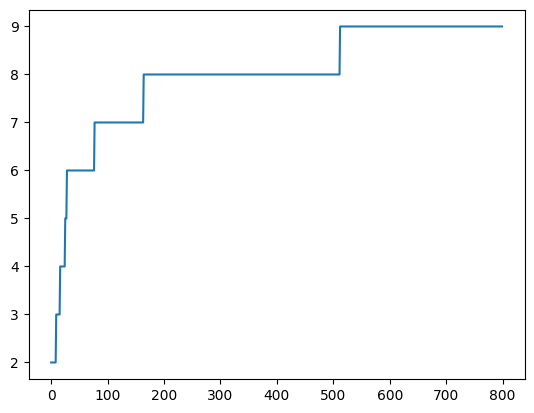

In [ ]:
model = ATLAS(doc_size=128, topic_rate=.01)
topics = model.fit_predict(data, locs, n_steps=800)
show_dataset(locs, topics, size=1)
plt.plot(range(len(model.log_)), model.log_)
plt.show()
plt.plot(range(len(model.topic_log_)), model.topic_log_)
plt.show()

In [10]:
model = GibbsSLDA(8, data_size=8)
slda_topics = model.fit_predict(data.numpy(), locs.numpy())
show_dataset(locs, slda_topics, size=1)
plt.plot(range(len(model.log_)), model.log_)
plt.show()

TypeError: _build() missing 2 required positional arguments: 'X' and 'locs'